In [104]:

import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Usando dispositivo: {device}")

Usando dispositivo: cpu


# Componentes Principales de PyTorch en los Modelos Desarrollados

Los modelos desarrollados en este cuaderno utilizan una estructura sólida y estandarizada basada en los principales objetos de la librería **PyTorch**:

* **`Dataset`:** Permite organizar, estructurar y acceder de manera eficiente a los datos (características y etiquetas) que se utilizan durante el entrenamiento y la evaluación.
* **`DataLoader`:** Facilita el manejo de los datos y su procesamiento en **lotes (batches)** durante el entrenamiento, además de permitir el barajado (*shuffle*) automático para evitar que el modelo aprenda el orden de las filas.
* **`nn.Module`:** Es la clase base obligatoria utilizada para construir cualquier modelo de red neuronal. Define las capas de la arquitectura en el método `__init__` y el flujo de los datos en el método `forward`.
* **Funciones de costo (Criterios):** Permiten medir matemáticamente el error entre las predicciones del modelo y los valores reales. En estos laboratorios se utilizan específicamente:
  * **`MSELoss`:** Error Cuadrático Medio, utilizado para problemas de regresión.
  * **`BCELoss`:** Entropía Cruzada Binaria, utilizada para problemas de clasificación binaria (2 clases).
  * **`CrossEntropyLoss`:** Entropía Cruzada, utilizada para problemas de clasificación multiclase (3 o más clases).
* **Optimizadores:** Algoritmos que permiten actualizar los parámetros (pesos y sesgos) del modelo durante el entrenamiento para reducir la función de costo. En los laboratorios se utilizan principalmente **`optim.SGD`** (Descenso por Gradiente Estocástico) y **`optim.Adam`** (un optimizador adaptativo y más eficiente).
* **Métricas:** Permiten evaluar y entender el rendimiento del modelo en términos humanos una vez finalizado el entrenamiento (ej. *Accuracy* en clasificación, o *R² y MAE* en regresión).
* **`state_dict`:** Un diccionario de Python que mapea cada capa con sus respectivas matrices de pesos aprendidos. Permite guardar y exportar los pesos en un archivo ligero (formato `.pth`) para poder conservar y reutilizar el resultado del entrenamiento sin necesidad de volver a entrenar la red desde cero.


Esta clase LaboratorioDataset sirve para preparar los datos para PyTorch. Recibe las entradas X y las etiquetas y, 
las convierte en tensores y define cómo acceder a cada dato. __len__ indica cuántos datos tenemos y __getitem__ 
permite obtener un dato específico junto con su etiqueta. Además, dependiendo del tipo de problema, las etiquetas 
se guardan como float32 para regresión o long para clasificación.

In [105]:
class LaboratorioDataset(Dataset):
 
    def __init__(self, X, y):
        # Conversión a tensores de PyTorch al inicializar
        self.X = torch.tensor(X, dtype=torch.float32)
        # Si es clasificación multiclase, las etiquetas deben ser de tipo Long (enteros)
        if len(y.shape) == 1 or y.shape[1] == 1:
            if y.dtype in [np.int32, np.int64, int]:
                self.y = torch.tensor(y, dtype=torch.long)
            else:
                self.y = torch.tensor(y, dtype=torch.float32)
        else:
            self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# Modelos de Redes Neuronales en PyTorch

### 1. Regresionsimple
Es el modelo más sencillo. Utiliza una sola capa `Linear`, que recibe las características de entrada (`D_in`) y genera una única salida. Se utiliza para realizar una regresión lineal simple, donde se busca obtener un valor numérico como resultado.

### 2. Regresion
Utiliza dos capas lineales. La primera transforma las características de entrada de `D_in` a `D_in // 2`, después se aplica la función de activación `ReLU` y finalmente una segunda capa `Linear` genera una sola salida. Este modelo se utiliza para problemas de regresión.

### 3. RegresionLogisticaBinaria
Tiene una estructura similar al modelo `Regresion`, con dos capas lineales y una función `ReLU` entre ellas. La diferencia principal es que al final utiliza `Sigmoid`, que transforma la salida del modelo. Este modelo se utiliza para clasificación binaria, es decir, cuando se tienen dos posibles clases.

### 4. ClasificadorMulticlase
Es el modelo utilizado para clasificación multiclase. Cuenta con tres capas lineales: la primera reduce las características de `D_in` a `D_in // 2`, la segunda a `D_in // 4` y la tercera genera una salida para cada una de las `num_classes`. También utiliza `BatchNorm1d`, `ReLU` y `Dropout` en las capas intermedias. Antes de procesar los datos, `torch.flatten` convierte la entrada en una forma adecuada para las capas lineales.


In [213]:

class Regresionsimple(nn.Module):
    def __init__(self, D_in):
        super(Regresionsimple, self).__init__()
        self.linear = nn.Linear(D_in, 1)
    def forward(self, x):
        return self.linear(x)

class Regresion(nn.Module):
    def __init__(self, D_in):
        super(Regresion, self).__init__()
        self.fc1 = nn.Linear(D_in, D_in //2)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(D_in //2, 1)
        
    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x
class RegresionLogisticaBinaria(nn.Module):
    def __init__(self, D_in):
        super(RegresionLogisticaBinaria, self).__init__()
        self.fc1 = nn.Linear(D_in, D_in //2)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(D_in //2, 1)
        self.sigmoid = nn.Sigmoid()
        
    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return self.sigmoid(x)

class ClasificadorMulticlase(nn.Module):
    def __init__(self, D_in, num_classes):
        super(ClasificadorMulticlase, self).__init__()

        self.fc1 = nn.Linear(D_in, D_in // 2)
        self.bn1 = nn.BatchNorm1d(D_in // 2)

        self.fc2 = nn.Linear(D_in // 2, D_in // 4)
        self.bn2 = nn.BatchNorm1d(D_in // 4)

        self.fc3 = nn.Linear(D_in // 4, num_classes)

        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.3)

    def forward(self, x):
        x = torch.flatten(x, start_dim=1)

        x = self.fc1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.dropout(x)

        x = self.fc2(x)
        x = self.bn2(x)
        x = self.relu(x)
        x = self.dropout(x)

        x = self.fc3(x)

        return x

### Función `guardar_pesos`

Esta función se encarga de almacenar en el disco duro los **parámetros aprendidos** (pesos y sesgos) por el modelo de PyTorch tras el entrenamiento.

**¿Cómo funciona paso a paso?**
* **Creación del directorio:** Revisa si la carpeta de destino (`save_dir`) existe. Si no existe, la crea automáticamente usando `os.makedirs`.
* **Ruta del archivo:** Une de forma segura el nombre de la carpeta y el nombre del archivo (`filename`) para generar la ruta completa de guardado.
* **Guardado eficiente:** Utiliza `torch.save(model.state_dict(), ...)` para guardar únicamente el diccionario de estados (`state_dict`). Esto almacena los valores numéricos de los pesos sin guardar la estructura completa de la clase del modelo, haciendo que el archivo final sea mucho más ligero (`.pth`).


In [107]:
def guardar_pesos(model, filename="modelo.pth", save_dir="./pesos"):
    """Guarda únicamente la matriz de pesos del modelo entrenado."""
    if not os.path.exists(save_dir):
        os.makedirs(save_dir)
    filepath = os.path.join(save_dir, filename)
    torch.save(model.state_dict(), filepath)
    print(f"-> Pesos del modelo guardados exitosamente en: '{filepath}'")

Regresion lineal simple 

In [108]:
df = pd.read_csv('../lab1/salary.txt')
X = df[['YearsExperience']].values
y = df[['Salary']].values

separamos los datos para test 20%  y train 80%

In [109]:
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42)
print(X_train.shape)
print(X_test.shape)

(28, 1)
(7, 1)


La normalización ajusta todos los datos para que estén en la misma escala (con valores cercanos a cero). 

In [110]:
mu, std = X_train.mean(axis=0), X_train.std(axis=0)
X_train_norm = (X_train - mu) / std
X_test_norm = (X_test - mu) / std

transforma las matrices de datos originales (usualmente de NumPy) en **tensores de PyTorch**, que es el formato de datos compatible que la red neuronal necesita para realizar sus operaciones.

* `torch.tensor(..., dtype=torch.float32)`: Convierte los datos al tipo **flotante de 32 bits**, el estándar recomendado para entrenar modelos de deep learning de forma eficiente.
* `.to(device)`: Envía los tensores a la memoria del procesador activo (usualmente la **GPU** en Colab para acelerar los cálculos, o la **CPU** si no hay una disponible).

In [111]:
# Conversión a tensores de PyTorch
X_train_s_tensor = torch.tensor(X_train_norm, dtype=torch.float32).to(device)
y_train_s_tensor = torch.tensor(y_train, dtype=torch.float32).to(device)
X_test_s_tensor = torch.tensor(X_test_norm, dtype=torch.float32).to(device)
y_test_s_tensor = torch.tensor(y_test, dtype=torch.float32).to(device)

### Configuración del Modelo de Regresión Simple

Este bloque de código define los hiperparámetros y los componentes esenciales para iniciar el entrenamiento:

* **`learning_rate_simple = 0.05`:** La tasa de aprendizaje. Determina qué tan grandes serán los pasos del modelo al ajustar sus pesos; un valor muy alto desestabiliza el entrenamiento y uno muy bajo lo hace lento.
* **`epochs_simple = 200`:** El número de épocas. Es la cantidad de veces completas que el modelo revisará todo el conjunto de datos de entrenamiento.
* **`model = Regresionsimple(1).to(device)`:** Inicializa la red neuronal indicando que recibirá una sola característica de entrada (`1`) y la envía al procesador activo (**GPU o CPU**).
* **`criterion = nn.MSELoss()`:** Define la función de pérdida del **Error Cuadrático Medio** (MSE). Mide qué tan lejos están las predicciones del modelo respecto a los valores reales.


In [112]:
learning_rate_simple = 0.05
epochs_simple = 200
model = Regresionsimple(1).to(device)
criterion = nn.MSELoss()

### Bucle de Entrenamiento Manual

Este código ejecuta el ciclo de aprendizaje del modelo durante **200 épocas**, ajustando los pesos paso a paso para minimizar el error sin usar un optimizador externo.

* **`model.train()`:** Activa el modo de entrenamiento en la red neuronal.
* **Forward pass (`y_pred` y `loss`):** El modelo realiza la predicción con los datos actuales y calcula el error (pérdida) en comparación con el valor real.
* **Backward pass (`loss.backward()`):** Calcula matemáticamente los gradientes (dirección y fuerza del error) para saber cómo modificar los pesos.
* **Actualización manual (`param -= ...`):** Ajusta los pesos restándoles el gradiente multiplicado por la tasa de aprendizaje y luego limpia los gradientes (`.zero_()`) para el siguiente ciclo.
* **`loss_history` e Impresión:** Guarda el progreso del error en una lista y muestra en pantalla el estado del entrenamiento cada 20 épocas.


In [113]:
loss_history = []

for epoch in range(epochs_simple):
    model.train()
    
    # Forward pass sobre conjunto de entrenamiento
    y_pred = model(X_train_s_tensor)
    loss = criterion(y_pred, y_train_s_tensor)
    
    # Backward pass y actualización manual de parámetros
    loss.backward()
    with torch.no_grad():
        for param in model.parameters():
            param -= learning_rate_simple * param.grad
            param.grad.zero_()
    
    loss_history.append(loss.item())
    
    if (epoch + 1) % 20 == 0:
        print(f'Época [{epoch+1}/{epochs_simple}], Pérdida MSE Train: {loss.item():.4f}')

Época [20/200], Pérdida MSE Train: 170405840.0000
Época [40/200], Pérdida MSE Train: 32951122.0000
Época [60/200], Pérdida MSE Train: 30919434.0000
Época [80/200], Pérdida MSE Train: 30889414.0000
Época [100/200], Pérdida MSE Train: 30888972.0000
Época [120/200], Pérdida MSE Train: 30888960.0000
Época [140/200], Pérdida MSE Train: 30888962.0000
Época [160/200], Pérdida MSE Train: 30888974.0000
Época [180/200], Pérdida MSE Train: 30888974.0000
Época [200/200], Pérdida MSE Train: 30888974.0000


### Evaluación Final del Modelo

Este bloque calcula el error final en los datos de prueba y compara los resultados para verificar qué tan bien aprendió el modelo.

* **model.eval() y torch.no_grad():** Configuran el modelo en modo de evaluación y congelan los pesos, ahorrando memoria al desactivar el cálculo de gradientes.
* **Predicción de Prueba:** Calcula el error (MSE) usando únicamente los datos de prueba (`X_test_s_tensor`).
* **Comparación (Train vs Test):** Muestra en pantalla las pérdidas finales de ambos conjuntos para comprobar si el modelo es capaz de generalizar correctamente con datos nuevos.


In [114]:
model.eval()
with torch.no_grad():
    y_pred_test = model(X_test_s_tensor)
    loss_test_s = criterion(y_pred_test, y_test_s_tensor)

print(f'Pérdida MSE Final en Entrenamiento (Train 80%): {loss_history[-1]:.4f}')
print(f'Pérdida MSE Final en Prueba (Test 20%): {loss_test_s.item():.4f}')

Pérdida MSE Final en Entrenamiento (Train 80%): 30888974.0000
Pérdida MSE Final en Prueba (Test 20%): 55762056.0000


## Gráficas de la regresión simple

Se muestran dos gráficas. La primera presenta la evolución de la pérdida MSE durante las épocas de entrenamiento. La segunda muestra los datos de entrenamiento y prueba junto con la recta de ajuste obtenida por el modelo.

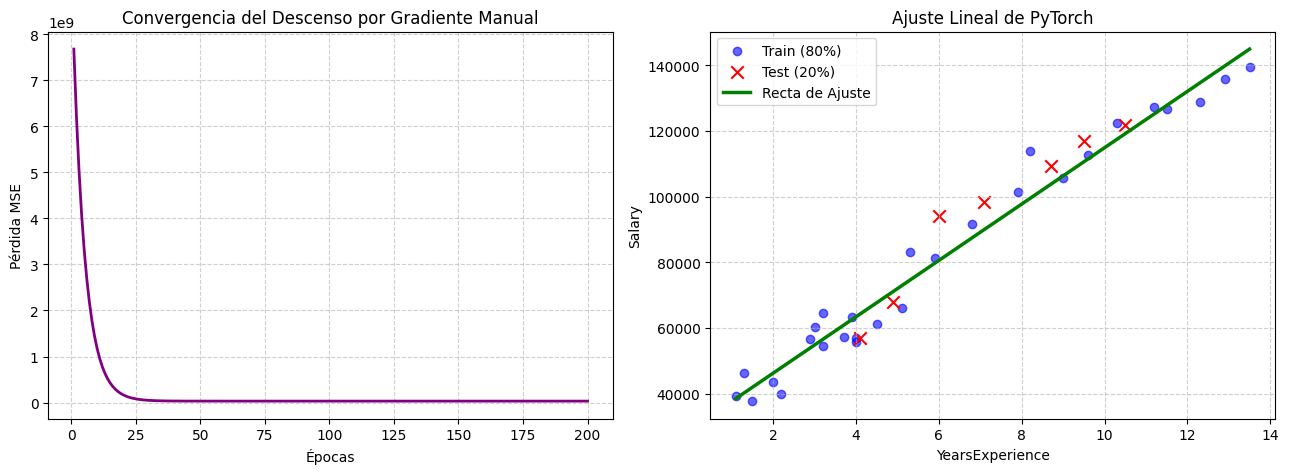

In [115]:
# Gráficas de la curva de costo y la recta de ajuste sobre Train y Test
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Curva de costo
ax1.plot(range(1, epochs_simple + 1), loss_history, color='purple', linewidth=2)
ax1.set_xlabel('Épocas')
ax1.set_ylabel('Pérdida MSE')
ax1.set_title('Convergencia del Descenso por Gradiente Manual')
ax1.grid(True, linestyle='--', alpha=0.6)

# Ajuste Lineal
ax2.scatter(X_train, y_train, color='blue', alpha=0.6, label='Train (80%)')
ax2.scatter(X_test, y_test, color='red', marker='x', s=80, label='Test (20%)')

x_range = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
x_range_norm = (x_range - mu) / std
x_range_tensor = torch.tensor(x_range_norm, dtype=torch.float32).to(device)
with torch.no_grad():
    y_range_pred = model(x_range_tensor).cpu().numpy()

ax2.plot(x_range, y_range_pred, color='green', linewidth=2.5, label='Recta de Ajuste')
ax2.set_xlabel('YearsExperience')
ax2.set_ylabel('Salary')
ax2.set_title('Ajuste Lineal de PyTorch')
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

# Regresión Lineal Múltiple, Polinómica y Ecuación de la Normal (Lab 3)

## Función general de entrenamiento

`entrenar_modelo` permite entrenar los modelos de regresión utilizando `DataLoader`. En cada lote se envían los datos al dispositivo, se reinician los gradientes, se realiza la predicción, se calcula la pérdida, se hace el `backward` y se actualizan los parámetros con el optimizador. Al final de cada época se calcula la pérdida promedio.

In [116]:
def entrenar_modelo(model, train_loader, dataset_total, criterion, optimizer, epochs=200, print_every=40, device='cpu'):
    """
    Función genérica para entrenar cualquier modelo de PyTorch (Regresión o Clasificación).
    """
    model.to(device)
    print("Iniciando entrenamiento...")
    
    for epoch in range(1, epochs + 1):
        model.train()
        running_loss = 0.0
        
        for batch_X, batch_y in train_loader:
            # Enviar datos al dispositivo (CPU o GPU)
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            
            # Reiniciar gradientes
            optimizer.zero_grad()
            
            # Forward pass
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            
            # Backward pass y optimización
            loss.backward()
            optimizer.step()
            
            # Acumular pérdida ponderada por el tamaño del batch
            running_loss += loss.item() * batch_X.size(0)
            
        # Calcular la pérdida promedio de la época
        epoch_loss = running_loss / len(dataset_total)
        
        # Controlar la frecuencia de los prints
        if epoch % print_every == 0 or epoch == 1:
            print(f"Época [{epoch}/{epochs}] - Pérdida Promedio: {epoch_loss:.4f}")
            
    print("¡Entrenamiento finalizado con éxito!\n")
    return model

## Evaluación de regresión

La función `evaluar_regresion` pone el modelo en modo evaluación y obtiene las predicciones del conjunto de prueba sin calcular gradientes. Después reúne predicciones y valores reales y utiliza `calcular_metricas` para obtener MSE, MAE y R².

In [117]:
def evaluar_regresion(model, test_loader, device='cpu'):
   
    model.to(device)
    model.eval()
    
    all_preds = []
    all_targets = []
    
    with torch.no_grad():
        for batch_X, batch_y in test_loader:
            batch_X = batch_X.to(device)
            predictions = model(batch_X)
            
            all_preds.append(predictions.cpu())
            all_targets.append(batch_y.cpu())
            
    all_preds = torch.cat(all_preds, dim=0).numpy()
    all_targets = torch.cat(all_targets, dim=0).numpy()
    
    if len(all_targets.shape) == 1:
        all_targets = all_targets.reshape(-1, 1)
    if len(all_preds.shape) == 1:
        all_preds = all_preds.reshape(-1, 1)
        
    mse, mae, r2 = calcular_metricas(all_targets, all_preds)
    

    print(f"-> Error Cuadrático Medio (MSE): {mse:.4f}")
    print(f"-> Error Absoluto Medio (MAE): {mae:.4f}")
    print(f"-> Coeficiente de Determinación (R²): {r2*100:.2f}%")
    print("=========================================\n")
    
    return all_preds, all_targets

## Métricas de regresión

La función calcula tres medidas: **MSE**, que representa el error cuadrático medio; **MAE**, que representa el error absoluto medio; y **R²**, que indica el coeficiente de determinación calculado a partir de la variación total y el error de las predicciones.

In [118]:
def calcular_metricas(y_true, y_pred):
    mse = np.mean((y_true - y_pred) ** 2)
    mae = np.mean(np.abs(y_true - y_pred))
    
    # Coeficiente de determinación R2
    y_bar = np.mean(y_true)
    ss_tot = np.sum((y_true - y_bar) ** 2)
    ss_res = np.sum((y_true - y_pred) ** 2)
    r2 = 1 - (ss_res / ss_tot) if ss_tot != 0 else 0.0
    
    return mse, mae, r2


Se carga `Reaction Network (Undirected).data`, tratando `?` como valores faltantes. Se eliminan las filas con datos faltantes. Las columnas desde la segunda hasta la penúltima forman `X`, mientras que la última columna se utiliza como `y`. También se muestran las dimensiones y el número de ejemplos.

In [119]:
df = pd.read_csv(
    "../lab3/Reaction Network (Undirected).data",  
    header=None,
    na_values=["?"]
)

# Ver forma y primeras filas
print(df.shape)
print(df.head())

df = df.dropna()

X = df.iloc[:, 1:-1].values   
y = df.iloc[:, -1].values     

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Número de ejemplos (m):", y.size)

(65554, 29)
         0   1   2   3         4    5         6         7         8   \
0  aac00010   1  15   8  0.086580  506  5.905138  2.260870  0.102767   
1  aac00020   1   7   5  0.091503  342  3.309942  2.526316  0.140351   
2  aac00030   2   8   1  0.177489  386  3.191710  2.434783  0.110672   
3  aac00040   5   5   1  0.087719   92  2.304348  1.500000  0.078947   
4  aac00051   2   5   1  0.196970  112  2.446429  2.000000  0.166667   

         9   ...        19        20        21         22   23        24  \
0  0.350401  ...  0.423671  0.233578  0.672991  11.739130  0.0  0.175792   
1  0.324091  ...  0.442857  0.135879  0.670008   5.789474  0.0  0.307019   
2  0.683255  ...  0.264447  0.150775  0.736842   5.478261  0.0  0.387645   
3  0.447214  ...  0.183333  0.184762  0.794286   2.900000  0.0  0.616221   
4  0.554700  ...  0.270192  0.138462  0.750769   3.538462  0.0  0.509972   

         25        26  27  28  
0  5.905138  0.181159  23  44  
1  3.309942  0.070175  19  44  
2 

In [120]:
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42)
print(X_train.shape)
print(X_test.shape)

(51686, 27)
(12922, 27)


Multivariable

`y_train` y `y_test` se reorganizan para tener una columna. Luego se calcula la media y desviación estándar de cada característica usando `X_train`.

In [121]:
y_train = y_train.reshape(-1, 1)
y_test = y_test.reshape(-1, 1)
mu, std = X_train.mean(axis=0), X_train.std(axis=0)
X_train_norm = (X_train - mu) / std
X_test_norm = (X_test - mu) / std

## Preparación y entrenamiento de la regresión multivariable

Se crean los `Dataset` y `DataLoader` para entrenamiento y prueba. Se utiliza el modelo `Regresion`, `MSELoss` como función de pérdida y el optimizador Adam con una tasa de aprendizaje de `0.001`. El modelo se entrena durante 100 épocas.

In [122]:
train_dataset = LaboratorioDataset(X_train_norm, y_train)
test_dataset = LaboratorioDataset(X_test_norm, y_test)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

model=Regresion(X_train_norm.shape[1]).to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

entrenar_modelo(model, train_loader, train_dataset, 
                criterion, optimizer, epochs=100, print_every=20, device=device)

Iniciando entrenamiento...
Época [1/100] - Pérdida Promedio: 103.6236
Época [20/100] - Pérdida Promedio: 2.2672
Época [40/100] - Pérdida Promedio: 1.9479
Época [60/100] - Pérdida Promedio: 1.8463
Época [80/100] - Pérdida Promedio: 1.7303
Época [100/100] - Pérdida Promedio: 1.6148
¡Entrenamiento finalizado con éxito!



Regresion(
  (fc1): Linear(in_features=27, out_features=13, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=13, out_features=1, bias=True)
)

Se llama a `evaluar_regresion` para obtener las predicciones del conjunto de prueba y calcular MSE, MAE y R². Estas métricas permiten medir el comportamiento del modelo en datos que no fueron utilizados durante el entrenamiento.

In [123]:
print("=========================================")
print("EVALUACIÓN: REGRESIÓN MULTIVARIABLE")
print("=========================================")
all_preds, all_targets = evaluar_regresion(model, test_loader, device='cpu')

EVALUACIÓN: REGRESIÓN MULTIVARIABLE
-> Error Cuadrático Medio (MSE): 4.6357
-> Error Absoluto Medio (MAE): 0.5565
-> Coeficiente de Determinación (R²): 98.71%



Después del entrenamiento se guardan los pesos aprendidos del modelo en el archivo `regresion_multivariable.pth`.

In [124]:
guardar_pesos(model, "regresion_multivariable.pth")

-> Pesos del modelo guardados exitosamente en: './pesos\regresion_multivariable.pth'


## Regresión polinómica

Para la versión polinómica se toma la tercera característica normalizada y se calcula su cuadrado. Después se agrega esta nueva característica a las demás mediante `np.hstack`, tanto para entrenamiento como para prueba. Así se amplía la entrada utilizada por el modelo.

In [125]:
x3_sq_train = (X_train_norm[:, 2:3]) ** 2
X_poly_train = np.hstack([X_train_norm, x3_sq_train])

x3_sq_test = (X_test_norm[:, 2:3]) ** 2
X_poly_test = np.hstack([X_test_norm, x3_sq_test])

## Entrenamiento de la regresión polinómica

Se crean nuevamente los `Dataset` y `DataLoader`, ahora utilizando las características originales junto con la característica al cuadrado. Se utiliza `Regresion`, `MSELoss` y Adam para entrenar durante 100 épocas.

In [126]:
train_dataset = LaboratorioDataset(X_poly_train, y_train)
test_dataset = LaboratorioDataset(X_poly_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

model=Regresion(X_poly_train.shape[1]).to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

entrenar_modelo(model, train_loader, train_dataset, 
                criterion, optimizer, epochs=100, print_every=20, device=device)

Iniciando entrenamiento...
Época [1/100] - Pérdida Promedio: 102.3882
Época [20/100] - Pérdida Promedio: 2.2160
Época [40/100] - Pérdida Promedio: 2.0154
Época [60/100] - Pérdida Promedio: 1.8934
Época [80/100] - Pérdida Promedio: 1.7777
Época [100/100] - Pérdida Promedio: 1.6180
¡Entrenamiento finalizado con éxito!



Regresion(
  (fc1): Linear(in_features=28, out_features=14, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=14, out_features=1, bias=True)
)

Se evalúa el modelo polinómico sobre el conjunto de prueba y se calculan las métricas MSE, MAE y R².

In [127]:
print("=========================================")
print("EVALUACIÓN: REGRESIÓN POLINOMIAL")
print("=========================================")
all_preds, all_targets = evaluar_regresion(model, test_loader, device='cpu')

EVALUACIÓN: REGRESIÓN POLINOMIAL
-> Error Cuadrático Medio (MSE): 5.0530
-> Error Absoluto Medio (MAE): 0.5361
-> Coeficiente de Determinación (R²): 98.60%



Los pesos aprendidos durante la regresión polinómica se guardan en `regresion_polinomial.pth`.

In [128]:
guardar_pesos(model, "regresion_polinomial.pth")

-> Pesos del modelo guardados exitosamente en: './pesos\regresion_polinomial.pth'


## Ecuación de la normal

En esta parte se convierten los datos a tensores y se agrega una columna de unos para representar el término independiente. Se calcula `theta_norm` mediante la pseudoinversa usando `torch.linalg.pinv`. Después se utilizan estos parámetros para obtener las predicciones del conjunto de prueba y se calculan MSE, MAE y R².

In [134]:
X_train_m_tensor = torch.tensor(X_train_norm, dtype=torch.float32).to(device)
y_train_m_tensor = torch.tensor(y_train, dtype=torch.float32).to(device)
X_test_m_tensor = torch.tensor(X_test_norm, dtype=torch.float32).to(device)
y_test_m_tensor = torch.tensor(y_test, dtype=torch.float32).to(device)


X_b_train = torch.cat([torch.ones((X_train_m_tensor.shape[0], 1), device=device), X_train_m_tensor], dim=1)
X_b_test = torch.cat([torch.ones((X_test_m_tensor.shape[0], 1), device=device), X_test_m_tensor], dim=1)

# θ = (X^T * X)^(-1) * X^T * y
theta_norm = torch.linalg.pinv(X_b_train.T @ X_b_train) @ X_b_train.T @ y_train_m_tensor

# Predicción sobre conjunto de Test (20%)
y_pred_test_tensor = X_b_test @ theta_norm

y_test_np = y_test_m_tensor.cpu().numpy()
y_pred_np = y_pred_test_tensor.cpu().numpy()

# Cálculo de métricas
mse, mae, r2 = calcular_metricas(y_test_np, y_pred_np)

print("=========================================")
print("EVALUACIÓN: ECUACIÓN DE LA NORMAL")
print("=========================================")
print(f"-> Error Cuadrático Medio (MSE): {mse:.4f}")
print(f"-> Error Absoluto Medio (MAE): {mae:.4f}")
print(f"-> Coeficiente de Determinación (R²): {r2*100:.2f}%")
print("=========================================\n")


EVALUACIÓN: ECUACIÓN DE LA NORMAL
-> Error Cuadrático Medio (MSE): 7.3859
-> Error Absoluto Medio (MAE): 0.9712
-> Coeficiente de Determinación (R²): 97.95%



# Regresión Logística Binaria (Lab 4)

## Función de entrenamiento para clasificación binaria

La función `fit` entrena el modelo por lotes. Para cada lote obtiene las predicciones, calcula la pérdida, realiza `backward` y actualiza los parámetros con el optimizador. También calcula la precisión (`accuracy`) usando un umbral de `0.5`. Después evalúa el modelo sobre el conjunto de prueba sin calcular gradientes.

In [ ]:
from tqdm import tqdm
def fit(model, criterion,optimizer,dataloader, epochs=5, PATH="./checkpoint.pt", print_every=1, device='cpu'):
    model.to(device)
    best_acc = 0

    for epoch in range(1, epochs + 1):
        model.train()
        train_loss = []
        train_acc = []
        bar = tqdm(dataloader['train'])

        for X, y in bar:
            X = X.to(device)
            y = y.to(device).float()
            optimizer.zero_grad()
            y_hat = model(X)
            loss = criterion(y_hat, y)
            loss.backward()
            optimizer.step()
            train_loss.append(loss.item())
            pred = (y_hat >= 0.5).float()
            acc = (pred == y).float().mean().item()
            train_acc.append(acc)
            bar.set_description(f"loss {np.mean(train_loss):.5f} "
                f"acc {np.mean(train_acc):.5f}")
        
        model.eval()
        val_loss = []
        val_acc = []
        bar = tqdm(dataloader['test'])

        with torch.no_grad():
            for X, y in bar:
                X = X.to(device)
                y = y.to(device).float()
                y_hat = model(X)
                loss = criterion(y_hat, y)
                val_loss.append(loss.item())
                pred = (y_hat >= 0.5).float()
                acc = (pred == y).float().mean().item()
                val_acc.append(acc)
                bar.set_description(
                    f"val_loss {np.mean(val_loss):.5f} "
                    f"val_acc {np.mean(val_acc):.5f}"
                )

        mean_val_acc = np.mean(val_acc)
        if mean_val_acc > best_acc:
            best_acc = mean_val_acc
            torch.save(model.state_dict(), PATH)
            print(f"Best model saved at epoch {epoch} "f"with val_acc {mean_val_acc:.5f}")
        if epoch % print_every == 0 or epoch == 1:
         print(f"Epoch {epoch}/{epochs} "f"loss {np.mean(train_loss):.5f} "
               f"val_loss {np.mean(val_loss):.5f} "f"acc {np.mean(train_acc):.5f} "
               f"val_acc {mean_val_acc:.5f}")
    model.load_state_dict(torch.load(PATH, map_location=device))

    return model


In [141]:
data = np.loadtxt('../lab4/ijcnn1.csv', delimiter=',',
                  skiprows=1)

X, y = data[:,:-1 ], data[:,0]


In [142]:
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42)
print(X_train.shape)
print(X_test.shape)

(73360, 22)
(18341, 22)


## Normalización de Lab 4

Las etiquetas se reorganizan para tener una columna. Las características se normalizan utilizando la media y desviación estándar calculadas sobre el conjunto de entrenamiento.

In [143]:
y_train = y_train.reshape(-1, 1)
y_test = y_test.reshape(-1, 1)
mu, std = X_train.mean(axis=0), X_train.std(axis=0)
X_train_norm = (X_train - mu) / std
X_test_norm = (X_test - mu) / std

## Preparación del modelo binario

Se crean los `Dataset` y `DataLoader`. Se utiliza `RegresionLogisticaBinaria`, `BCELoss` como función de pérdida y Adam con una tasa de aprendizaje de `0.001`. El modelo produce una salida mediante `Sigmoid`, adecuada para la clasificación binaria utilizada en este laboratorio.

In [144]:
train_dataset = LaboratorioDataset(X_train_norm, y_train)
test_dataset = LaboratorioDataset(X_test_norm, y_test)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

model = RegresionLogisticaBinaria(X_train_norm.shape[1]).to(device)
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

## Entrenamiento de la clasificación binaria

Se llama a `fit` para entrenar el modelo durante 5 épocas utilizando los conjuntos de entrenamiento y prueba. Los pesos se guardan en la ruta indicada.

In [158]:
fit(model, criterion, optimizer, {'train': train_loader, 'test': test_loader}, epochs=5, PATH="./pesos/binario.pt.pt")

val_loss 0.00000 val_acc 1.00000: 100%|██████████| 574/574 [00:00<00:00, 1252.84it/s]


Best model saved at epoch 1 with val_acc 1.00000
Epoch 1/5 loss 0.00000 val_loss 0.00000 acc 1.00000 val_acc 1.00000


val_loss 0.00000 val_acc 1.00000: 100%|██████████| 574/574 [00:00<00:00, 1278.85it/s]


Epoch 2/5 loss 0.00000 val_loss 0.00000 acc 1.00000 val_acc 1.00000


val_loss 0.00000 val_acc 1.00000: 100%|██████████| 574/574 [00:00<00:00, 1304.83it/s]


...

val_loss 0.00000 val_acc 1.00000: 100%|██████████| 574/574 [00:00<00:00, 1289.32it/s]


Epoch 4/5 loss 0.00000 val_loss 0.00000 acc 1.00000 val_acc 1.00000


val_loss 0.00000 val_acc 1.00000: 100%|██████████| 574/574 [00:00<00:00, 1222.32it/s]


Epoch 5/5 loss 0.00000 val_loss 0.00000 acc 1.00000 val_acc 1.00000


RegresionLogisticaBinaria(
  (fc1): Linear(in_features=22, out_features=11, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=11, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)

## Evaluación de clasificación binaria

La función `evaluate` obtiene las predicciones del conjunto de prueba. Cada salida se convierte en una clase utilizando el umbral `0.5`. Luego se calcula la precisión comparando las clases predichas con las etiquetas reales

In [163]:
def evaluate(model, dataloader, device='cpu'):
    model.eval()
    model.to(device)
    
    bar = tqdm(dataloader)
    acc_list = []
    
    with torch.no_grad():
        for batch in bar:
            X, y = batch
            X, y = X.to(device), y.to(device).float()
            
            y = y.view(-1, 1)
            
            y_hat = model(X)
            
            predicciones_clase = (y_hat >= 0.5).float()
            
            aciertos = (predicciones_clase == y).sum().item()
            accuracy_batch = aciertos / len(y)
            
            acc_list.append(accuracy_batch)
            bar.set_description(f"acc {np.mean(acc_list):.5f}")
            
    accuracy_final = np.mean(acc_list)
    print(f"\n Accuracy Final en el Conjunto de Test: {accuracy_final * 100:.2f}%")
    
    return accuracy_final

## Accuracy en el conjunto de prueba

Se ejecuta la función de evaluación sobre `test_loader` para obtener la precisión final del modelo en el conjunto de prueba.

In [164]:
evaluate(model, test_loader)

acc 1.00000: 100%|██████████| 574/574 [00:00<00:00, 1445.28it/s]


 Accuracy Final en el Conjunto de Test: 100.00%


np.float64(1.0)

## Matriz de confusión binaria

Se recopilan las etiquetas reales y las predicciones del modelo. Después se construye la matriz de confusión con `confusion_matrix` y se muestra mediante `ConfusionMatrixDisplay`, diferenciando las clases 0 y 1.

Matriz de Confusión:
[[16634     0]
 [    0  1707]]


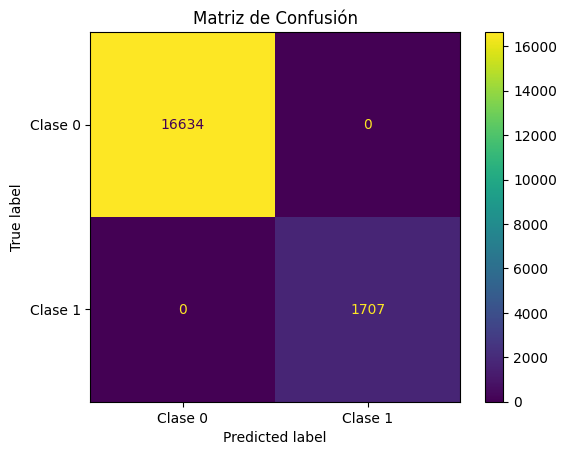

In [162]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


model.eval()

y_true = []
y_pred = []

with torch.no_grad():
    for X, y in test_loader:
        X = X.to(device)
        y = y.to(device).float()

        y_hat = model(X)

        pred = (y_hat >= 0.5).float()

        y_true.extend(y.cpu().numpy())
        y_pred.extend(pred.cpu().numpy())

cm = confusion_matrix(y_true, y_pred)

print("Matriz de Confusión:")
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Clase 0", "Clase 1"]
)

disp.plot()
plt.title("Matriz de Confusión")
plt.show()

# Clasificación Multiclase (Lab 5)

Se utiliza `ImageFolder` para cargar las imágenes organizadas por clases. Cada imagen se redimensiona a `32 x 32`, se convierte a tensor y se normaliza usando media y desviación estándar de `0.5` para los tres canales. Finalmente se obtiene el número de clases, sus nombres y el número total de imágenes.

In [214]:
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split


DATA_ROOT = "../lab5/images"
IMG_SIZE = 32
BATCH_SIZE = 32


transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.5, 0.5, 0.5],
        std=[0.5, 0.5, 0.5]
    )
])

dataset = datasets.ImageFolder(
    root=DATA_ROOT,
    transform=transform
)

clases = dataset.classes
num_labels = len(clases)

print("Número de clases:", num_labels)
print("Clases:", clases)
print("Número de imágenes:", len(dataset))


Número de clases: 101
Clases: ['apple_pie', 'baby_back_ribs', 'baklava', 'beef_carpaccio', 'beef_tartare', 'beet_salad', 'beignets', 'bibimbap', 'bread_pudding', 'breakfast_burrito', 'bruschetta', 'caesar_salad', 'cannoli', 'caprese_salad', 'carrot_cake', 'ceviche', 'cheese_plate', 'cheesecake', 'chicken_curry', 'chicken_quesadilla', 'chicken_wings', 'chocolate_cake', 'chocolate_mousse', 'churros', 'clam_chowder', 'club_sandwich', 'crab_cakes', 'creme_brulee', 'croque_madame', 'cup_cakes', 'deviled_eggs', 'donuts', 'dumplings', 'edamame', 'eggs_benedict', 'escargots', 'falafel', 'filet_mignon', 'fish_and_chips', 'foie_gras', 'french_fries', 'french_onion_soup', 'french_toast', 'fried_calamari', 'fried_rice', 'frozen_yogurt', 'garlic_bread', 'gnocchi', 'greek_salad', 'grilled_cheese_sandwich', 'grilled_salmon', 'guacamole', 'gyoza', 'hamburger', 'hot_and_sour_soup', 'hot_dog', 'huevos_rancheros', 'hummus', 'ice_cream', 'lasagna', 'lobster_bisque', 'lobster_roll_sandwich', 'macaroni_and_

El conjunto de imágenes se divide en 80 % para entrenamiento y el resto para prueba utilizando `random_split`.

In [215]:
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size

train_dataset, test_dataset = random_split(
    dataset,
    [train_size, test_size]
)

## Configuración del clasificador multiclase

Se crean los `DataLoader` para entrenamiento y prueba. El modelo recibe `3 * 32 * 32` valores por imagen, correspondientes a los tres canales y las dimensiones de la imagen. Se utiliza `ClasificadorMulticlase`, `CrossEntropyLoss` y Adam con una tasa de aprendizaje de `0.001`.

In [216]:
train_loader = DataLoader(train_dataset,batch_size=128,shuffle=True)

test_loader = DataLoader( test_dataset, batch_size=64, shuffle=False)

model =ClasificadorMulticlase (3* 32 *32,num_labels).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam( model.parameters(),lr=0.001)

## Entrenamiento del clasificador multiclase

La función `fitOVA` entrena el modelo por lotes. Las etiquetas se convierten a `long`, se calculan las predicciones y la pérdida, y se actualizan los parámetros. Para obtener la clase predicha se utiliza `torch.argmax` sobre las salidas del modelo. También se calcula la precisión durante el entrenamiento y la validación.

In [218]:
from tqdm import tqdm

def fitOVA(model, criterion, optimizer, dataloader, epochs=5, PATH="./checkpoint.pt",
        print_every=1, device='cpu'):
    model.to(device)
    best_acc = 0
    for epoch in range(1, epochs + 1):


        model.train()
        train_loss = []
        train_acc = []
        bar = tqdm(dataloader['train'])
        for X, y in bar:
            X = X.to(device)
            y = y.to(device).long()
            optimizer.zero_grad()
            y_hat = model(X)
            loss = criterion(y_hat, y)
            loss.backward()
            optimizer.step()
            train_loss.append(loss.item())
            # Predicción para varias clases
            pred = torch.argmax(y_hat, dim=1)
            acc = (pred == y).float().mean().item()
            train_acc.append(acc)
            bar.set_description(
                f"loss {np.mean(train_loss):.5f} "
                f"acc {np.mean(train_acc):.5f}"
            )
        model.eval()
        val_loss = []
        val_acc = []
        bar = tqdm(dataloader['test'])
        with torch.no_grad():
            for X, y in bar:
                X = X.to(device)
                y = y.to(device).long()
                y_hat = model(X)
                loss = criterion(y_hat, y)
                val_loss.append(loss.item())
                pred = torch.argmax(y_hat, dim=1)
                acc = (pred == y).float().mean().item()
                val_acc.append(acc)
                bar.set_description( f"val_loss {np.mean(val_loss):.5f} "f"val_acc {np.mean(val_acc):.5f}")
        mean_val_acc = np.mean(val_acc)
        if mean_val_acc > best_acc:
            best_acc = mean_val_acc
            torch.save(
                model.state_dict(),
                PATH
            )
            print(f"Best model saved at epoch {epoch} "f"with val_acc {mean_val_acc:.5f}")

        if epoch % print_every == 0 or epoch == 1:
            print(f"Epoch {epoch}/{epochs} "f"loss {np.mean(train_loss):.5f} " f"val_loss {np.mean(val_loss):.5f} "
                f"acc {np.mean(train_acc):.5f} " f"val_acc {mean_val_acc:.5f}")
    model.load_state_dict(
        torch.load(PATH, map_location=device)
    )

    return model

## Entrenamiento final del modelo multiclase

Se ejecuta `fitOVA` durante 10 épocas y se utiliza el archivo indicado para guardar el entrenamiento.

In [ ]:
fitOVA(model, criterion, optimizer, {'train': train_loader, 'test': test_loader}, 
       epochs=10, PATH="./pesos/clases.pt.pt",print_every=2)

val_loss 4.14519 val_acc 0.07609: 100%|██████████| 253/253 [00:34<00:00,  7.44it/s]


Best model saved at epoch 1 with val_acc 0.07609
Epoch 1/10 loss 4.33672 val_loss 4.14519 acc 0.05238 val_acc 0.07609


val_loss 4.06982 val_acc 0.09029: 100%|██████████| 253/253 [00:30<00:00,  8.35it/s]


Best model saved at epoch 2 with val_acc 0.09029
Epoch 2/10 loss 4.12109 val_loss 4.06982 acc 0.08004 val_acc 0.09029


val_loss 4.01231 val_acc 0.10227: 100%|██████████| 253/253 [00:29<00:00,  8.45it/s]


...

val_loss 3.92196 val_acc 0.12117: 100%|██████████| 253/253 [03:43<00:00,  1.13it/s]


Best model saved at epoch 8 with val_acc 0.12117
Epoch 8/10 loss 3.60964 val_loss 3.92196 acc 0.15733 val_acc 0.12117


val_loss 3.92740 val_acc 0.12000: 100%|██████████| 253/253 [01:04<00:00,  3.90it/s]

Epoch 10/10 loss 3.44401 val_loss 3.92740 acc 0.18411 val_acc 0.12000


ClasificadorMulticlase(
  (fc1): Linear(in_features=3072, out_features=1536, bias=True)
  (bn1): BatchNorm1d(1536, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (fc2): Linear(in_features=1536, out_features=768, bias=True)
  (bn2): BatchNorm1d(768, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (fc3): Linear(in_features=768, out_features=101, bias=True)
  (relu): ReLU()
  (dropout): Dropout(p=0.3, inplace=False)
)

## Evaluación del modelo multiclase

La función `evaluate` obtiene las predicciones del conjunto de prueba. Para cada ejemplo se selecciona la clase con el valor mayor mediante `torch.argmax` y se compara con la etiqueta real para calcular la precisión.

In [220]:
def evaluate(model, dataloader):
    model.eval()
    model.to(device)
    bar = tqdm(dataloader)
    acc = []
    with torch.no_grad():
        for batch in bar:
            X, y = batch
            X, y = X.to(device), y.to(device)
            y_hat = model(X)
            acc.append((y == torch.argmax(y_hat, axis=1)).sum().item() / len(y))
            bar.set_description(f"acc {np.mean(acc):.5f}")

In [221]:
evaluate(model, test_loader)

acc 0.12117: 100%|██████████| 253/253 [00:29<00:00,  8.64it/s]


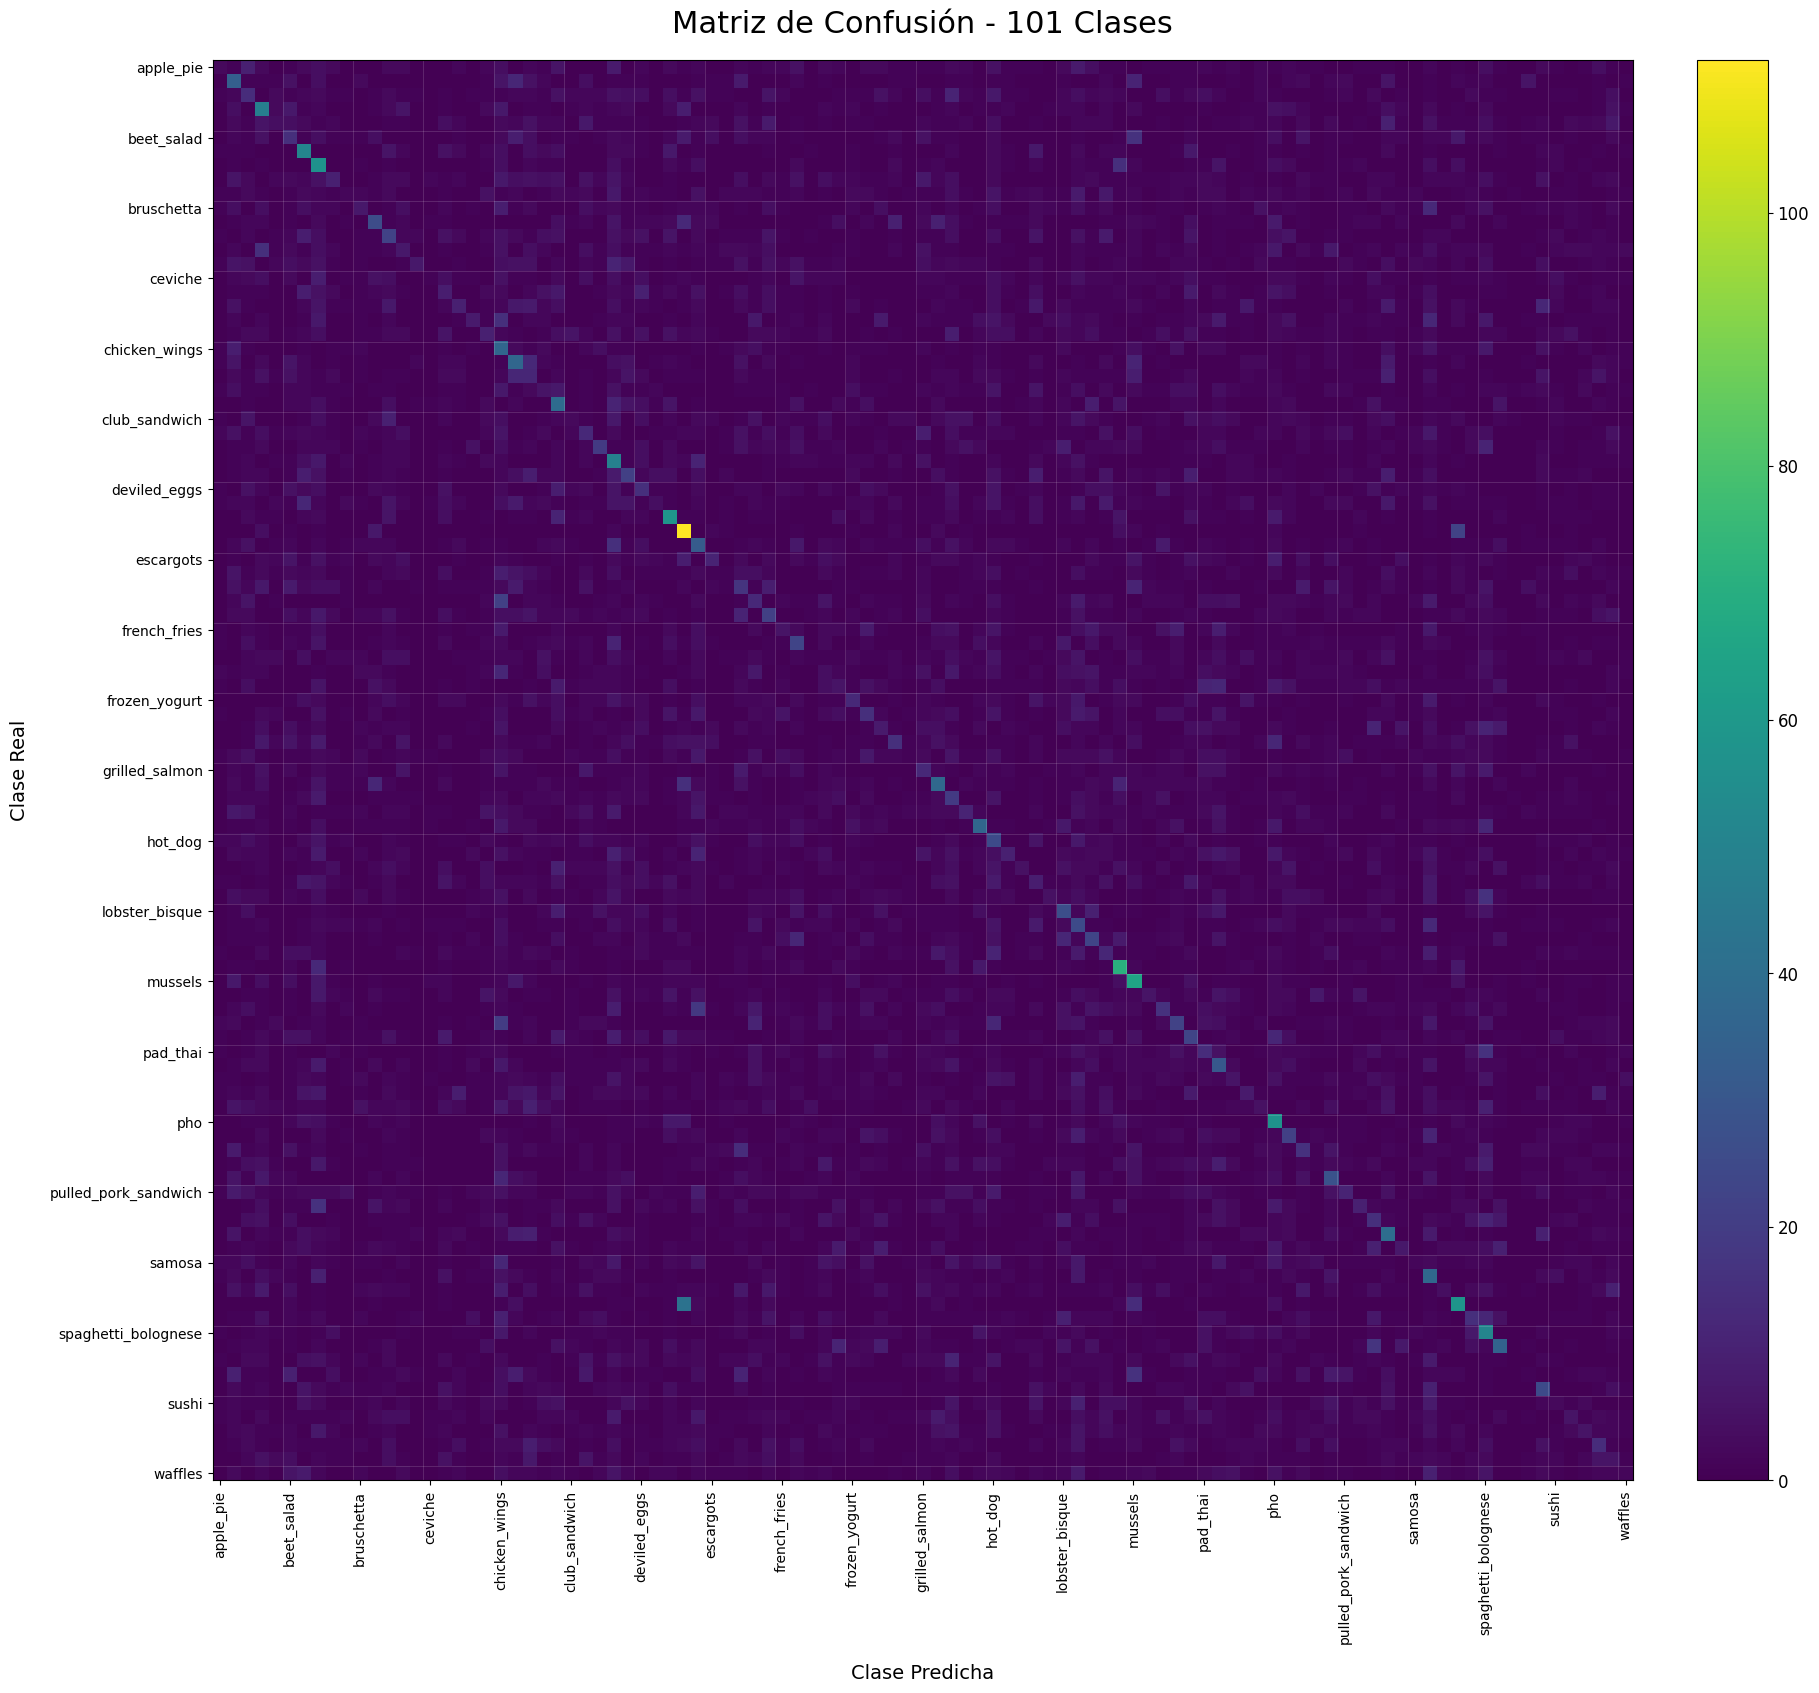

In [224]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# 1. Configurar el modelo en modo evaluación y enviarlo al dispositivo activo
model.eval()
model.to(device)

y_true = []
y_pred = []

# 2. Extraer las predicciones del conjunto de prueba
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)

        outputs = model(images)
        predictions = torch.argmax(outputs, dim=1)

        y_true.extend(labels.numpy())
        y_pred.extend(predictions.cpu().numpy())

# 3. Calcular la matriz de confusión de 101 x 101 clases
cm = confusion_matrix(
    y_true,
    y_pred,
    labels=range(num_labels)
)

# 4. Crear la figura (Se mantiene un tamaño grande para albergar las clases)
fig, ax = plt.subplots(figsize=(22, 20))

# Graficar la matriz de confusión
im = ax.imshow(cm, interpolation='nearest', cmap='viridis')

# Título y etiquetas de los ejes
ax.set_title("Matriz de Confusión - 101 Clases", fontsize=22, pad=20)
ax.set_xlabel("Clase Predicha", fontsize=14, labelpad=15)
ax.set_ylabel("Clase Real", fontsize=14, labelpad=15)

# 5. Configurar el paso (mostrar 1 de cada 5 etiquetas para evitar saturación)
paso = 5

ax.set_xticks(np.arange(0, num_labels, paso))
ax.set_yticks(np.arange(0, num_labels, paso))

ax.set_xticklabels(
    [clases[i] for i in range(0, num_labels, paso)],
    rotation=90,
    fontsize=10
)

ax.set_yticklabels(
    [clases[i] for i in range(0, num_labels, paso)],
    fontsize=10
)

# 6. Cuadrícula guía sutil (ayuda visual para seguir las filas/columnas espaciadas)
ax.set_xticks(np.arange(-0.5, num_labels, paso), minor=True)
ax.set_yticks(np.arange(-0.5, num_labels, paso), minor=True)
ax.grid(which='minor', color='w', linestyle='-', linewidth=0.5, alpha=0.2)
ax.tick_params(which='minor', bottom=False, left=False)

# 7. Barra de colores optimizada para que no deforme el tamaño de la matriz
cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.ax.tick_params(labelsize=12)

# 8. SOLUCIÓN AL CORTE: Ajuste de márgenes manual (reemplaza a tight_layout)
# left=0.22 reserva el 22% del espacio izquierdo para los nombres del eje Y
# bottom=0.22 reserva el 22% del espacio inferior para los nombres rotados del eje X
plt.subplots_adjust(left=0.22, bottom=0.22, right=0.95, top=0.93)

# 9. Mostrar la gráfica de forma limpia y garantizada
plt.show()

plt.show()